In [31]:
import numpy as np
import tensorflow as tf
import random

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical


In [33]:
X = np.load("../X_data.npy")
y = np.load("../y_user.npy")

print("Normalization öncesi:")
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Std:", np.std(X))

X_normalized = []

for sample in X:

    sample_mean = np.mean(sample)
    sample_std = np.std(sample)

    sample = (
        sample - sample_mean
    ) / (sample_std + 1e-8)

    X_normalized.append(sample)

X = np.array(X_normalized)

print("Shape:", X.shape)

print("Mean:", np.mean(X))
print("Std:", np.std(X))
print("\nNormalization sonrası:")
print("Min:", np.min(X))
print("Max:", np.max(X))
print("Mean:", np.mean(X))
print("Std:", np.std(X))

Normalization öncesi:
Min: -128.0
Max: 127.0
Mean: 0.10197854
Std: 21.693716
Shape: (747, 100, 64)
Mean: 8.777123e-11
Std: 1.0000002

Normalization sonrası:
Min: -6.220304
Max: 6.105876
Mean: 8.777123e-11
Std: 1.0000002


In [34]:
user_names = {
    0: "aleyna",
    1: "damla",
    2: "deniz",
    3: "derya"
}

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
# Gaussian Noise
noise = np.random.normal(
    0,
    0.02,
    X_train.shape
)

X_noise = X_train + noise


# Temporal Shift
def temporal_shift(sample, shift=5):
    return np.roll(sample, shift, axis=0)

X_shifted = np.array([
    temporal_shift(
        x,
        shift=np.random.randint(-5,5)
    )
    for x in X_train
])


# Combine
X_train_final = np.concatenate([
    X_train,
    X_noise,
    X_shifted
], axis=0)

y_train_final = np.concatenate([
    y_train,
    y_train,
    y_train
], axis=0)

In [37]:
num_classes = len(np.unique(y))

y_train_cat = to_categorical(
    y_train_final,
    num_classes
)

y_test_cat = to_categorical(
    y_test,
    num_classes
)

print(y_train_cat.shape)

(1791, 4)


In [38]:
model = Sequential([

    Conv1D(
        32,
        kernel_size=3,
        activation='relu',
        input_shape=(100,64)
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        64,
        kernel_size=3,
        activation='relu'
    ),

    MaxPooling1D(pool_size=2),

    LSTM(64),

    Dropout(0.5),

    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/opt/anaconda3/envs/csi_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
history = model.fit(
    X_train_final,
    y_train_cat,

    validation_data=(
        X_test,
        y_test_cat
    ),

    epochs=25,
    batch_size=16
)

Epoch 1/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.2630 - loss: 1.4213 - val_accuracy: 0.3200 - val_loss: 1.3694
Epoch 2/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.3512 - loss: 1.2891 - val_accuracy: 0.5267 - val_loss: 1.1354
Epoch 3/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4947 - loss: 1.1156 - val_accuracy: 0.6600 - val_loss: 0.9599
Epoch 4/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5807 - loss: 0.9869 - val_accuracy: 0.5467 - val_loss: 0.9553
Epoch 5/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6025 - loss: 0.9304 - val_accuracy: 0.6067 - val_loss: 0.9216
Epoch 6/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6092 - loss: 0.9237 - val_accuracy: 0.5933 - val_loss: 0.9789
Epoch 7/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6644 - loss: 0.8246 - val_accuracy: 0.6667 - val_loss: 0.8064
Epoch 8/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7164 - loss: 0.6947 - val_accu

In [40]:
loss, acc = model.evaluate(X_test, y_test_cat)

print("Final Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8067 - loss: 0.9220
Final Test Accuracy: 0.8066666722297668


In [41]:
predictions = model.predict(X_test)

pred_classes = np.argmax(predictions, axis=1)

print(classification_report(
    y_test,
    pred_classes,
    target_names=list(user_names.values())
))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
              precision    recall  f1-score   support

      aleyna       0.81      0.90      0.85        42
       damla       0.86      0.86      0.86        36
       deniz       0.90      0.53      0.67        36
       derya       0.72      0.92      0.80        36

    accuracy                           0.81       150
   macro avg       0.82      0.80      0.80       150
weighted avg       0.82      0.81      0.80       150



In [42]:
import random

# Rastgele test örneği seç
idx = random.randint(0, len(X_test)-1)

test_sample = X_test[idx]
true_user_id = y_test[idx]

# Batch boyutu ekle
sample_input = np.expand_dims(test_sample, axis=0)

# Tahmin yap
prediction = model.predict(sample_input)

predicted_user_id = np.argmax(prediction)

# Mapping
id_to_user = {
    0: "aleyna",
    1: "damla",
    2: "deniz",
    3: "derya"
}

print("------ CSI USER TEST DEMO ------")
print(f"Gerçek Kullanıcı : {id_to_user.get(true_user_id)}")
print(f"Tahmin Edilen    : {id_to_user.get(predicted_user_id)}")

confidence = np.max(prediction) * 100

print(f"Güven Skoru      : %{confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
------ CSI USER TEST DEMO ------
Gerçek Kullanıcı : damla
Tahmin Edilen    : damla
Güven Skoru      : %98.42


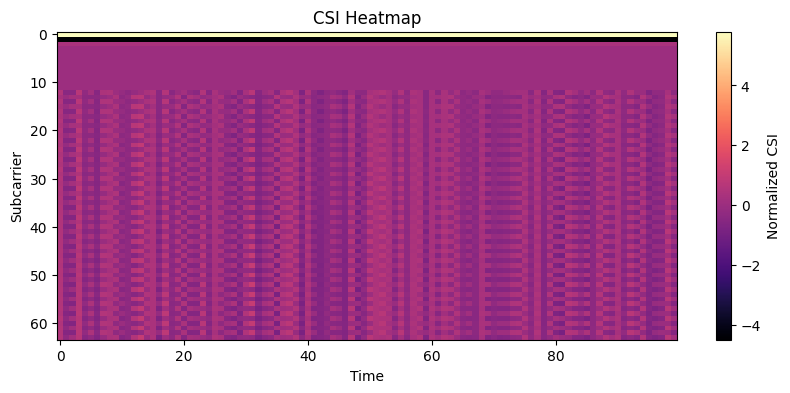

In [43]:
plt.figure(figsize=(10,4))

plt.imshow(test_sample.T,
           aspect='auto',
           cmap='magma')

plt.title("CSI Heatmap")

plt.xlabel("Time")
plt.ylabel("Subcarrier")

plt.colorbar(label="Normalized CSI")

plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


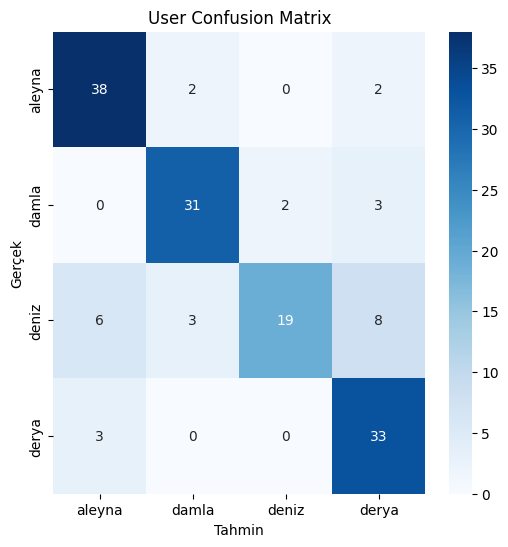

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = model.predict(X_test)

pred_classes = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(user_names.values()),
    yticklabels=list(user_names.values())
)

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("User Confusion Matrix")

plt.show()

In [47]:
model.save("../models/MULTI_SESSION_MODEL.h5")